1. the data we need to gather - all major leagues that take part in the champions league
2. champions league matches
3. build files that check the current data and compare them
4. build elo system that doesnt track too much back - transfers team changes etc but through past matches it needs to build starting elo especially between teams within the national leagues, with games in the eurpean club tournamets acting as the true information about the teams state
5. build functions that can update that data every day/week/ round of champions league
6. build model that can predict match result
7. think about features that i want the model to ingest.

#1. We start with importing Libraries

In [1]:
from curl_cffi import requests
import pandas as pd
import os

In [2]:
# SofaScore tournament + season IDs, found via DevTools / the search & seasons endpoints.
# Each tuple: (competition name, tournament_id, season_label, season_id)
COMPETITIONS = [
    ("Champions League", 7,   "2026/27", 96518),
    ("Champions League", 7,   "2025/26", 76953),
    ("Europa League",    679, "2026/27", 96522),
    ("Europa League",    679, "2025/26", 76984),
    ("Premier League",   17,  "2026/27", 96668),
    ("Premier League",   17,  "2025/26", 76986),
    ("La Liga",          8,   "2026/27", 97268),
    ("La Liga",          8,   "2025/26", 77559),
    ("Bundesliga",       35,  "2026/27", 97464),
    ("Bundesliga",       35,  "2025/26", 77333),
    ("Serie A",          23,  "2026/27", 95836),
    ("Serie A",          23,  "2025/26", 76457),
    ("Ligue 1",          34,  "2026/27", 96127),
    ("Ligue 1",          34,  "2025/26", 77356),
]

In [3]:
import time

def fetch_new_events(tournament_id, season_id, since=pd.Timestamp.min):
    """Finished matches newer than `since`. Pages back until it hits older matches."""
    events, page = [], 0
    while True:
        url = f"https://www.sofascore.com/api/v1/unique-tournament/{tournament_id}/season/{season_id}/events/last/{page}"
        data = requests.get(url, impersonate="chrome").json()
        page_events = data["events"]
        new = [e for e in page_events if pd.to_datetime(e["startTimestamp"], unit="s") > since]
        events.extend(new)

        reached_known_matches = len(new) < len(page_events)
        if reached_known_matches or not data.get("hasNextPage"):
            break
        page += 1
        time.sleep(0.3)  # be a bit polite between requests
    return events

In [4]:
if os.path.exists("matches.csv"):
    matches_df = pd.read_csv("matches.csv", parse_dates=["date"])
else:
    matches_df = pd.DataFrame(columns=["competition", "season", "date", "home_team", "away_team", "home_score", "away_score"])

new_rows = []
for competition, tournament_id, season_label, season_id in COMPETITIONS:
    existing = matches_df[(matches_df["competition"] == competition) & (matches_df["season"] == season_label)]
    latest_date = existing["date"].max() if not existing.empty else pd.Timestamp.min

    for e in fetch_new_events(tournament_id, season_id, since=latest_date):
        new_rows.append({
            "competition": competition,
            "season": season_label,
            "date": pd.to_datetime(e["startTimestamp"], unit="s"),
            "home_team": e["homeTeam"]["name"],
            "away_team": e["awayTeam"]["name"],
            "home_score": e["homeScore"].get("current"),
            "away_score": e["awayScore"].get("current"),
        })

if new_rows:
    matches_df = pd.concat([matches_df, pd.DataFrame(new_rows)], ignore_index=True)
    matches_df.to_csv("matches.csv", index=False)

print(f"added {len(new_rows)} new matches")
matches_df.shape

added 0 new matches


(2771, 7)

In [5]:
matches_df.head()

,competition,season,date,home_team,away_team,home_score,away_score
0,Champions League,2026/27,2026-08-18 19:00:00,Fenerbahçe,Olympique Lyonnais,1.0,1.0
1,Champions League,2026/27,2026-08-19 19:00:00,Hapoel Be'er Sheva,Sabah FK,2.0,1.0
2,Champions League,2026/27,2026-08-19 19:00:00,ŠK Slovan Bratislava,NK Celje,1.0,1.0
3,Champions League,2026/27,2026-08-19 19:00:00,NEC Nijmegen,Bodø/Glimt,1.0,3.0
4,Champions League,2026/27,2026-08-19 19:00:00,Celtic,LASK,3.0,0.0


In [6]:
DEFAULT_RATING = 1500
K = 20

def expected_result(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

def actual_result(score_a, score_b):
    if score_a > score_b:
        return 1
    if score_a < score_b:
        return 0
    return 0.5

In [7]:
def compute_elo(matches_df):
    """Load cached Elo results, fill in only whatever matches are missing/new."""
    elo_cols = ["home_elo_before", "away_elo_before", "home_elo_after", "away_elo_after"]

    if os.path.exists("elo.csv"):
        old_elo = pd.read_csv("elo.csv", parse_dates=["date"])
        elo_df = matches_df.merge(old_elo[["date", "home_team", "away_team"] + elo_cols],
                                   on=["date", "home_team", "away_team"], how="left")
    else:
        elo_df = matches_df.assign(**{c: pd.NA for c in elo_cols})

    elo_df = elo_df.sort_values("date").reset_index(drop=True)

    ratings = {}
    for _, row in elo_df[elo_df["home_elo_after"].notna()].iterrows():
        ratings[row["home_team"]] = row["home_elo_after"]
        ratings[row["away_team"]] = row["away_elo_after"]

    new_matches = elo_df[elo_df["home_elo_after"].isna()]

    for i, m in new_matches.iterrows():
        home_elo = ratings.get(m["home_team"], DEFAULT_RATING)
        away_elo = ratings.get(m["away_team"], DEFAULT_RATING)

        expected_home = expected_result(home_elo, away_elo)
        result_home = actual_result(m["home_score"], m["away_score"])

        new_home_elo = home_elo + K * (result_home - expected_home)
        new_away_elo = away_elo + K * ((1 - result_home) - (1 - expected_home))

        elo_df.loc[i, elo_cols] = [home_elo, away_elo, new_home_elo, new_away_elo]

        ratings[m["home_team"]] = new_home_elo
        ratings[m["away_team"]] = new_away_elo

    if not new_matches.empty:
        elo_df.to_csv("elo.csv", index=False)

    print(f"processed {len(new_matches)} new matches, {len(ratings)} teams rated")
    return elo_df

In [8]:
elo_df = compute_elo(matches_df)
elo_df.tail()

processed 0 new matches, 256 teams rated


,competition,season,date,home_team,away_team,home_score,away_score,home_elo_before,away_elo_before,home_elo_after,away_elo_after
2766,La Liga,2026/27,2026-09-20 16:30:00,Villarreal,Levante UD,3.0,1.0,1500.127586,1474.129142,1509.380685,1464.876044
2767,Bundesliga,2026/27,2026-09-20 17:30:00,SC Paderborn 07,TSG Hoffenheim,3.0,1.0,1489.982933,1530.307823,1501.138393,1519.152364
2768,Serie A,2026/27,2026-09-20 18:45:00,AC Milan,Lecce,3.0,0.0,1555.834282,1457.925898,1563.088552,1450.671628
2769,Ligue 1,2026/27,2026-09-20 18:45:00,Olympique de Marseille,Paris Saint-Germain,1.0,2.0,1493.389696,1655.175034,1487.736521,1660.828209
2770,La Liga,2026/27,2026-09-20 19:00:00,Valencia,Real Sociedad,2.0,3.0,1483.717113,1467.498616,1473.250646,1477.965084


#2. Predicting the next round

In [9]:
def fetch_upcoming(tournament_id, season_id):
    """Not-yet-played fixtures for just the next round."""
    url = f"https://www.sofascore.com/api/v1/unique-tournament/{tournament_id}/season/{season_id}/events/next/0"
    data = requests.get(url, impersonate="chrome").json()
    events = data["events"]
    next_round = events[0]["roundInfo"]["round"]
    return [e for e in events if e["roundInfo"]["round"] == next_round]

In [10]:
# rebuild current ratings from elo_df, same as compute_elo does internally
current_ratings = {}
for _, row in elo_df[elo_df["home_elo_after"].notna()].iterrows():
    current_ratings[row["home_team"]] = row["home_elo_after"]
    current_ratings[row["away_team"]] = row["away_elo_after"]

CL_TOURNAMENT_ID, CL_SEASON_ID = 7, 96518
upcoming = fetch_upcoming(CL_TOURNAMENT_ID, CL_SEASON_ID)

predictions = []
for e in upcoming:
    home, away = e["homeTeam"]["name"], e["awayTeam"]["name"]
    home_elo = current_ratings.get(home, DEFAULT_RATING)
    away_elo = current_ratings.get(away, DEFAULT_RATING)
    home_win_lean = expected_result(home_elo, away_elo)
    favorite = home if home_win_lean >= 0.5 else away
    favorite_prob = max(home_win_lean, 1 - home_win_lean)
    predictions.append({
        "date": pd.to_datetime(e["startTimestamp"], unit="s"),
        "home_team": home, "away_team": away,
        "home_win_lean": home_win_lean,
        "favorite": favorite, "favorite_prob": favorite_prob,
    })

predictions_df = pd.DataFrame(predictions)
print(f"Round {upcoming[0]['roundInfo']['round']} — {len(predictions_df)} matches")

Round 2 — 18 matches


In [11]:
predictions_df.sort_values("favorite_prob", ascending=False)[["date", "home_team", "away_team", "favorite", "favorite_prob"]]

,date,home_team,away_team,favorite,favorite_prob
5,2026-10-13 19:00:00,Viking FK,FC Bayern München,FC Bayern München,0.779926
2,2026-10-13 19:00:00,Galatasaray,FC Barcelona,FC Barcelona,0.771286
10,2026-10-14 16:45:00,Feyenoord,Como,Como,0.694369
4,2026-10-13 19:00:00,Arsenal,Lille,Arsenal,0.682574
6,2026-10-13 19:00:00,Inter,Club Brugge KV,Inter,0.674241
13,2026-10-14 19:00:00,Bodø/Glimt,Borussia Dortmund,Borussia Dortmund,0.621638
9,2026-10-14 16:45:00,LASK,Liverpool FC,Liverpool FC,0.600301
1,2026-10-13 16:45:00,Sabah FK,SK Slavia Praha,Sabah FK,0.595687
8,2026-10-13 19:00:00,RB Leipzig,PSV Eindhoven,RB Leipzig,0.588008
15,2026-10-14 19:00:00,Real Betis,FC Porto,Real Betis,0.582875


#3. Browsing the data

In [12]:
# last 50 matches overall, with each team's Elo before and after the game
browse_cols = ["competition", "season", "date", "home_team", "away_team", "home_score", "away_score",
               "home_elo_before", "away_elo_before", "home_elo_after", "away_elo_after"]
elo_df.sort_values("date", ascending=False).head(50)[browse_cols]

,competition,season,date,home_team,away_team,home_score,away_score,home_elo_before,away_elo_before,home_elo_after,away_elo_after
2770,La Liga,2026/27,2026-09-20 19:00:00,Valencia,Real Sociedad,2.0,3.0,1483.717113,1467.498616,1473.250646,1477.965084
2769,Ligue 1,2026/27,2026-09-20 18:45:00,Olympique de Marseille,Paris Saint-Germain,1.0,2.0,1493.389696,1655.175034,1487.736521,1660.828209
2768,Serie A,2026/27,2026-09-20 18:45:00,AC Milan,Lecce,3.0,0.0,1555.834282,1457.925898,1563.088552,1450.671628
2767,Bundesliga,2026/27,2026-09-20 17:30:00,SC Paderborn 07,TSG Hoffenheim,3.0,1.0,1489.982933,1530.307823,1501.138393,1519.152364
2766,La Liga,2026/27,2026-09-20 16:30:00,Villarreal,Levante UD,3.0,1.0,1500.127586,1474.129142,1509.380685,1464.876044
2765,La Liga,2026/27,2026-09-20 16:30:00,Deportivo de A Coruña,Real Betis,1.0,1.0,1506.970502,1594.955316,1509.450127,1592.475691
2764,Serie A,2026/27,2026-09-20 16:00:00,Juventus,Atalanta,2.0,0.0,1587.518934,1527.049730,1595.795853,1518.772811
2762,Premier League,2026/27,2026-09-20 15:30:00,Fulham,Manchester United,1.0,1.0,1474.243064,1591.951213,1477.507043,1588.687235
2763,Bundesliga,2026/27,2026-09-20 15:30:00,FC Schalke 04,SV 07 Elversberg,0.0,0.0,1504.374179,1515.489742,1504.694001,1515.169919
2761,Ligue 1,2026/27,2026-09-20 15:15:00,Nice,Lille,2.0,1.0,1410.902720,1565.302593,1425.075558,1551.129756


In [13]:
# last 10 matches per competition, with each team's Elo after the game
elo_df.sort_values("date").groupby("competition").tail(10).sort_values(["competition", "date"])[browse_cols]

,competition,season,date,home_team,away_team,home_score,away_score,home_elo_before,away_elo_before,home_elo_after,away_elo_after
2685,Bundesliga,2026/27,2026-09-13 15:30:00,SV 07 Elversberg,FC Bayern München,1.0,2.0,1520.437238,1713.726555,1515.489742,1718.674051
2723,Bundesliga,2026/27,2026-09-18 18:30:00,FC Bayern München,1. FC Union Berlin,7.0,0.0,1718.674051,1447.061888,1722.136879,1443.599061
2732,Bundesliga,2026/27,2026-09-19 13:30:00,Eintracht Frankfurt,SC Freiburg,2.0,2.0,1461.846943,1556.154308,1464.496571,1553.504680
2733,Bundesliga,2026/27,2026-09-19 13:30:00,Borussia M'gladbach,1. FSV Mainz 05,3.0,4.0,1453.769670,1493.228309,1444.900523,1502.097456
2734,Bundesliga,2026/27,2026-09-19 13:30:00,Hamburger SV,1. FC Köln,2.0,1.0,1452.741532,1441.618618,1462.421498,1431.938652
...,...,...,...,...,...,...,...,...,...,...,...
2751,Serie A,2026/27,2026-09-20 10:30:00,Fiorentina,SSC Napoli,1.0,1.0,1474.010207,1564.587694,1476.559736,1562.038164
2756,Serie A,2026/27,2026-09-20 13:00:00,Parma,Genoa,2.0,1.0,1462.222539,1443.057774,1471.671491,1433.608822
2757,Serie A,2026/27,2026-09-20 13:00:00,Frosinone,Como,2.0,0.0,1509.396683,1616.184638,1522.377022,1603.204299
2764,Serie A,2026/27,2026-09-20 16:00:00,Juventus,Atalanta,2.0,0.0,1587.518934,1527.049730,1595.795853,1518.772811


#4. How good is the Elo model so far?

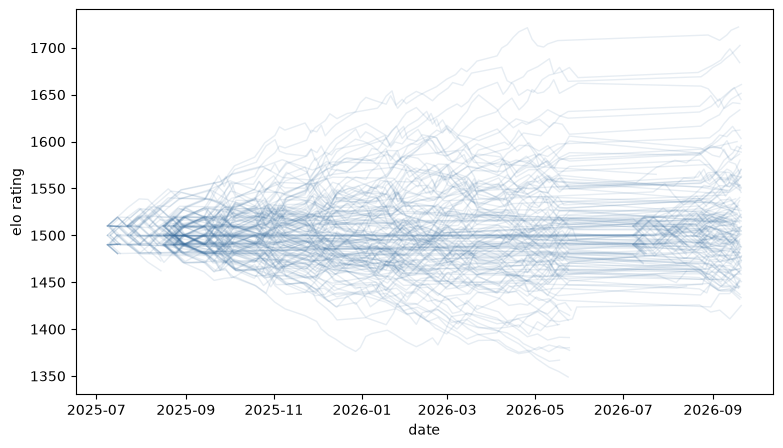

In [14]:
# plot every team's Elo rating over time to see stabilization (or lack of it) visually
import matplotlib.pyplot as plt

home_part = elo_df[["date", "home_team", "home_elo_after"]].rename(columns={"home_team": "team", "home_elo_after": "elo"})
away_part = elo_df[["date", "away_team", "away_elo_after"]].rename(columns={"away_team": "team", "away_elo_after": "elo"})
team_history = pd.concat([home_part, away_part]).dropna().sort_values(["team", "date"])

fig, ax = plt.subplots(figsize=(9, 5))
for team, grp in team_history.groupby("team"):
    ax.plot(grp["date"], grp["elo"], color="#3B6FA0", alpha=0.12, linewidth=1)
ax.set_ylabel("elo rating")
ax.set_xlabel("date")
plt.show()

In [15]:
# how often does Elo (rating before the match) correctly pick the winner?
import numpy as np

valid = elo_df.dropna(subset=["home_score", "away_score", "home_elo_before", "away_elo_before"]).copy()

def actual_winner(row):
    if row["home_score"] > row["away_score"]:
        return "home"
    if row["home_score"] < row["away_score"]:
        return "away"
    return "draw"

valid["actual_winner"] = valid.apply(actual_winner, axis=1)
valid["predicted_winner"] = np.where(valid["home_elo_before"] > valid["away_elo_before"], "home", "away")
valid["correct"] = valid["predicted_winner"] == valid["actual_winner"]

decisive = valid[valid["actual_winner"] != "draw"]
print(f"matches: {len(valid)}")
print(f"draw rate: {(valid['actual_winner'] == 'draw').mean():.1%}")
print(f"overall accuracy (draws count as misses): {valid['correct'].mean():.1%}")
print(f"accuracy on decisive (non-draw) matches: {(decisive['predicted_winner'] == decisive['actual_winner']).mean():.1%}")

matches: 2757
draw rate: 23.5%
overall accuracy (draws count as misses): 47.6%
accuracy on decisive (non-draw) matches: 62.2%


In [16]:
# does accuracy improve when the Elo gap between the two teams is bigger?
valid["elo_diff"] = (valid["home_elo_before"] - valid["away_elo_before"]).abs()

bins = [0, 50, 100, 150, 200, 300, float("inf")]
labels = ["0-50", "50-100", "100-150", "150-200", "200-300", "300+"]
valid["elo_diff_bucket"] = pd.cut(valid["elo_diff"], bins=bins, labels=labels)

valid.groupby("elo_diff_bucket")["correct"].agg(["mean", "count"])

,mean,count
elo_diff_bucket,,
0-50,0.429856,1668
50-100,0.533113,604
100-150,0.560976,246
150-200,0.785714,98
200-300,0.666667,27


#5. EDA — visualizing the model

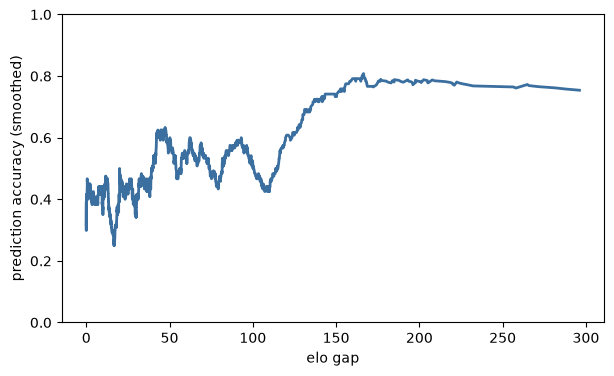

In [17]:
import matplotlib.pyplot as plt

BLUE = "#3B6FA0"
ORANGE = "#C97A3D"
GRAY = "#8A8F98"

# accuracy vs elo gap, smoothed (rolling mean over matches sorted by gap size)
by_gap = valid.sort_values("elo_diff").reset_index(drop=True)
by_gap["smoothed_accuracy"] = by_gap["correct"].rolling(120, center=True, min_periods=40).mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(by_gap["elo_diff"], by_gap["smoothed_accuracy"], color=BLUE, linewidth=2)
ax.set_ylabel("prediction accuracy (smoothed)")
ax.set_xlabel("elo gap")
ax.set_ylim(0, 1)
plt.show()

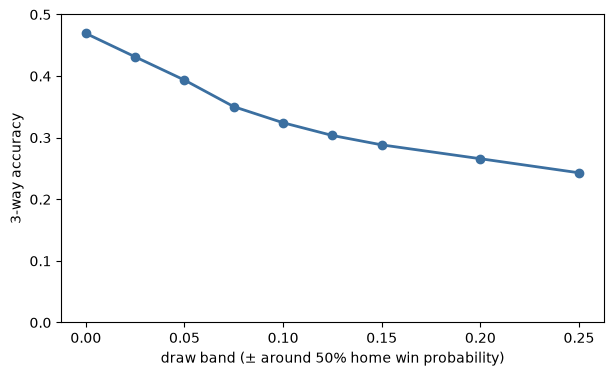

In [18]:
# does predicting "draw" for close matches (home_prob near 50%) improve 3-way accuracy?
# band=0 means never predict draw (pick whichever side is >50%); wider band predicts
# draw whenever the match looks close enough.
valid["home_prob"] = expected_result(valid["home_elo_before"], valid["away_elo_before"])

def three_way_accuracy(band):
    lo, hi = 0.5 - band, 0.5 + band

    def predict(p):
        if p < lo:
            return "away"
        if p > hi:
            return "home"
        return "draw"

    predicted = valid["home_prob"].apply(predict)
    return (predicted == valid["actual_winner"]).mean()

bands = [0, 0.025, 0.05, 0.075, 0.10, 0.125, 0.15, 0.20, 0.25]
band_accuracy = pd.Series({b: three_way_accuracy(b) for b in bands})

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(band_accuracy.index, band_accuracy.values, color=BLUE, marker="o", linewidth=2)
ax.set_xlabel("draw band (± around 50% home win probability)")
ax.set_ylabel("3-way accuracy")
ax.set_ylim(0, 0.5)
plt.show()

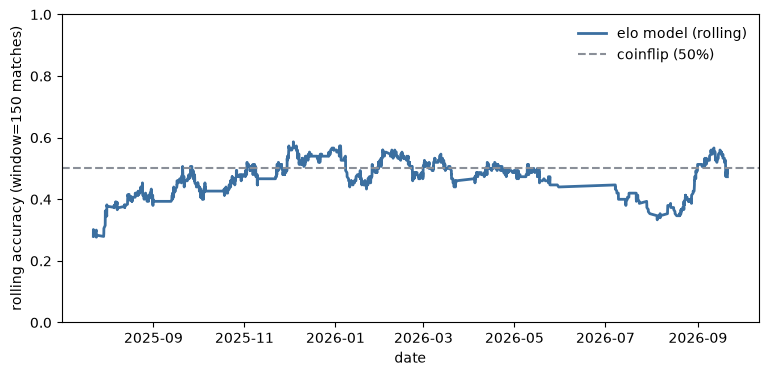

In [19]:
# does accuracy improve as the database accumulates more matches over time?
valid_sorted = valid.sort_values("date").reset_index(drop=True)
rolling_acc = valid_sorted["correct"].rolling(150, min_periods=50).mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(valid_sorted["date"], rolling_acc, color=BLUE, linewidth=2, label="elo model (rolling)")
ax.axhline(0.5, color=GRAY, linewidth=1.5, linestyle="--", label="coinflip (50%)")
ax.set_ylabel("rolling accuracy (window=150 matches)")
ax.set_xlabel("date")
ax.set_ylim(0, 1)
ax.legend(frameon=False)
plt.show()

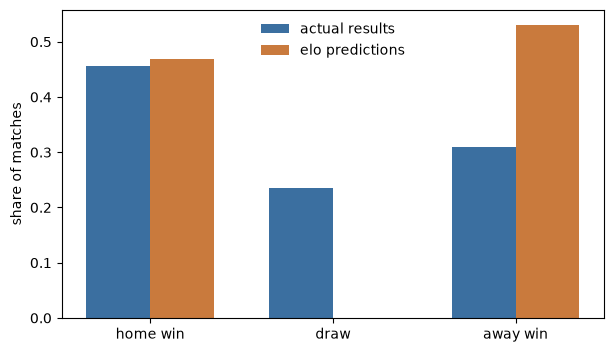

In [20]:
# home advantage: real results vs what plain elo (no home boost) predicts
actual_dist = valid["actual_winner"].value_counts(normalize=True).reindex(["home", "draw", "away"])
predicted_dist = valid["predicted_winner"].value_counts(normalize=True).reindex(["home", "away"]).reindex(["home", "draw", "away"]).fillna(0)

x = np.arange(3)
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width / 2, actual_dist.values, width, label="actual results", color=BLUE)
ax.bar(x + width / 2, predicted_dist.values, width, label="elo predictions", color=ORANGE)
ax.set_xticks(x)
ax.set_xticklabels(["home win", "draw", "away win"])
ax.set_ylabel("share of matches")
ax.legend(frameon=False)
plt.show()

In [ ]:
# "double chance": when the home team has any elo edge, how often do they at least avoid losing (win or draw)?
valid["elo_diff_signed"] = valid["home_elo_before"] - valid["away_elo_before"]
home_favored = valid[valid["elo_diff_signed"] > 0].copy()
home_favored["double_chance_correct"] = home_favored["actual_winner"] != "away"
home_favored["win_only_correct"] = home_favored["actual_winner"] == "home"
home_favored = home_favored.sort_values("elo_diff_signed").reset_index(drop=True)

home_favored["dc_smooth"] = home_favored["double_chance_correct"].rolling(100, center=True, min_periods=30).mean()
home_favored["wo_smooth"] = home_favored["win_only_correct"].rolling(100, center=True, min_periods=30).mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(home_favored["elo_diff_signed"], home_favored["dc_smooth"], color=BLUE, linewidth=2, label="home win or draw")
ax.plot(home_favored["elo_diff_signed"], home_favored["wo_smooth"], color=ORANGE, linewidth=2, label="home win only")
ax.set_xlabel("elo advantage (home favored by)")
ax.set_ylabel("accuracy (smoothed)")
ax.set_ylim(0, 1)
ax.legend(frameon=False)
plt.show()

print(f"overall double-chance accuracy when home is favored: {home_favored['double_chance_correct'].mean():.1%}")
print(f"overall win-only accuracy when home is favored: {home_favored['win_only_correct'].mean():.1%}")

Calibration check: the win-lean numbers we show for predictions (e.g. "77% Barcelona") are only useful if they're *honest* probabilities. This checks that — among all matches where Elo said "roughly 70% home win", did the home team actually win about 70% of the time? If the dots sit on the diagonal, the percentages can be trusted as real probabilities. If they sit off it, the model is over- or under-confident and the percentages are directionally right but numerically misleading.

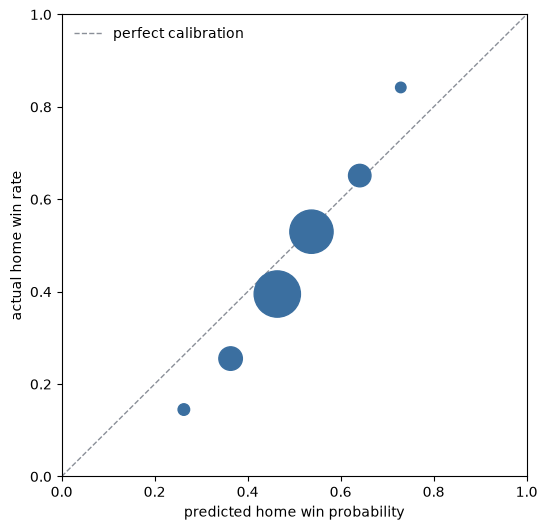

In [22]:
# calibration: when elo says "70% home win", does that actually happen ~70% of the time?
valid["home_prob"] = expected_result(valid["home_elo_before"], valid["away_elo_before"])
bins2 = [0, .3, .4, .5, .6, .7, .8, 1.0]
valid["prob_bucket"] = pd.cut(valid["home_prob"], bins=bins2)

calib = valid.groupby("prob_bucket").agg(
    predicted=("home_prob", "mean"),
    actual=("actual_winner", lambda x: (x == "home").mean()),
    n=("home_prob", "size"),
)
calib = calib[calib["n"] >= 20]

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], color=GRAY, linewidth=1, linestyle="--", label="perfect calibration")
ax.scatter(calib["predicted"], calib["actual"], s=calib["n"], color=BLUE, zorder=3)
ax.set_xlabel("predicted home win probability")
ax.set_ylabel("actual home win rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False)
plt.show()

In [23]:
# biggest upsets in the 2026/27 season, once both teams have "converged" (played enough matches to have a settled rating)
CONVERGED_AFTER = 10  # matches played

home_part = valid[["date", "home_team"]].rename(columns={"home_team": "team"})
away_part = valid[["date", "away_team"]].rename(columns={"away_team": "team"})
team_matches = pd.concat([home_part, away_part]).sort_values(["team", "date"])
team_matches["match_number"] = team_matches.groupby("team").cumcount() + 1
match_number = team_matches.drop_duplicates(subset=["date", "team"]).set_index(["date", "team"])["match_number"]

valid["home_match_number"] = valid.set_index(["date", "home_team"]).index.map(match_number)
valid["away_match_number"] = valid.set_index(["date", "away_team"]).index.map(match_number)

converged = valid[(valid["home_match_number"] > CONVERGED_AFTER) & (valid["away_match_number"] > CONVERGED_AFTER)]
this_season = converged[converged["season"] == "2026/27"]
upsets = this_season[(this_season["actual_winner"] != "draw") & (this_season["predicted_winner"] != this_season["actual_winner"])]

upset_cols = ["date", "competition", "home_team", "away_team", "home_score", "away_score", "home_elo_before", "away_elo_before", "elo_diff"]
upsets.sort_values("elo_diff", ascending=False).head(10)[upset_cols]

,date,competition,home_team,away_team,home_score,away_score,home_elo_before,away_elo_before,elo_diff
2736,2026-09-19 14:00:00,Premier League,Brighton & Hove Albion,Arsenal,3.0,0.0,1522.408953,1698.814239,176.405286
2761,2026-09-20 15:15:00,Ligue 1,Nice,Lille,2.0,1.0,1410.902720,1565.302593,154.399873
2593,2026-09-05 13:30:00,Bundesliga,SV Werder Bremen,RB Leipzig,3.0,1.0,1423.681047,1575.550780,151.869734
2541,2026-08-29 13:30:00,Bundesliga,1. FC Köln,TSG Hoffenheim,3.0,2.0,1435.655510,1551.156423,115.500914
2601,2026-09-05 14:15:00,La Liga,Athletic Club,Atlético Madrid,3.0,0.0,1450.580511,1565.204115,114.623604
2688,2026-09-13 18:45:00,Serie A,Sassuolo,Juventus,3.0,2.0,1482.660566,1593.073378,110.412812
2588,2026-09-04 19:05:00,Ligue 1,Paris Saint-Germain,AS Monaco,1.0,2.0,1656.240228,1546.837358,109.402870
2547,2026-08-29 15:00:00,La Liga,Levante UD,Real Betis,5.0,2.0,1465.944956,1570.613331,104.668375
2760,2026-09-20 14:15:00,La Liga,Atlético Madrid,Real Madrid,2.0,1.0,1557.350882,1657.581618,100.230736
2493,2026-08-23 13:00:00,Premier League,Brighton & Hove Albion,Aston Villa,4.0,0.0,1511.136314,1605.799554,94.663241
